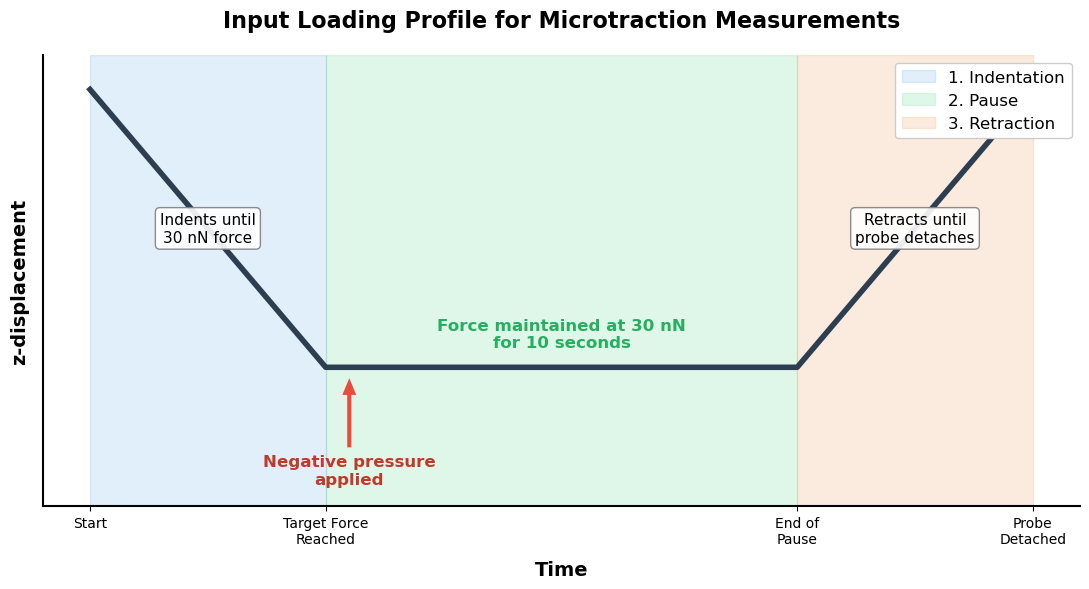

In [1]:
import matplotlib.pyplot as plt

# Define schematic time points (assuming 5s for indent/retract for visual symmetry)
t_indent = 5
t_pause = 10
t_retract = 5

t = [0, t_indent, t_indent + t_pause, t_indent + t_pause + t_retract]
# Z-displacement (using an arbitrary scale to match the "bucket" shape of the original)
z = [10, 2, 2, 10]

# Setup the figure
fig, ax = plt.subplots(figsize=(11, 6))

# Plot the main displacement profile
ax.plot(t, z, color='#2c3e50', linewidth=4)

# Shade and delineate the three distinct regions
ax.axvspan(0, t[1], alpha=0.15, color='#3498db', label='1. Indentation')
ax.axvspan(t[1], t[2], alpha=0.15, color='#2ecc71', label='2. Pause')
ax.axvspan(t[2], t[3], alpha=0.15, color='#e67e22', label='3. Retraction')

# Add explicit annotations from the caption directly into the plot
bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.9)

ax.text(t[1]/2, 6, 'Indents until\n30 nN force', ha='center', va='center', 
        fontsize=11, bbox=bbox_props)
        
ax.text(t[1] + t_pause/2, 2.5, 'Force maintained at 30 nN\nfor 10 seconds', 
        ha='center', va='bottom', fontsize=12, fontweight='bold', color='#27ae60')
        
ax.text(t[2] + t_retract/2, 6, 'Retracts until\nprobe detaches', ha='center', va='center', 
        fontsize=11, bbox=bbox_props)

# Emphasize the negative pressure application
ax.annotate('Negative pressure\napplied', xy=(t[1] + 0.5, 1.8), xytext=(t[1] + 0.5, -0.5),
            arrowprops=dict(facecolor='#e74c3c', shrink=0.05, width=3, headwidth=10, edgecolor='none'),
            ha='center', va='top', fontsize=12, color='#c0392b', fontweight='bold')

# Formatting axes and titles
ax.set_xlabel('Time', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('z-displacement', fontsize=14, fontweight='bold', labelpad=10)
ax.set_title('Input Loading Profile for Microtraction Measurements', fontsize=16, fontweight='bold', pad=20)

# Customize ticks to reflect the physical events rather than arbitrary numbers
ax.set_yticks([]) # Hide arbitrary y-axis numbers
ax.set_xticks([0, t[1], t[2], t[3]])
ax.set_xticklabels(['Start', 'Target Force\nReached', 'End of\nPause', 'Probe\nDetached'], fontsize=10)

# Clean up the visual layout
ax.legend(loc='upper right', fontsize=12, framealpha=1)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# Adjust y-limits to make room for the bottom arrow
plt.ylim(-2, 11)
plt.tight_layout()

# Display the plot
plt.show()

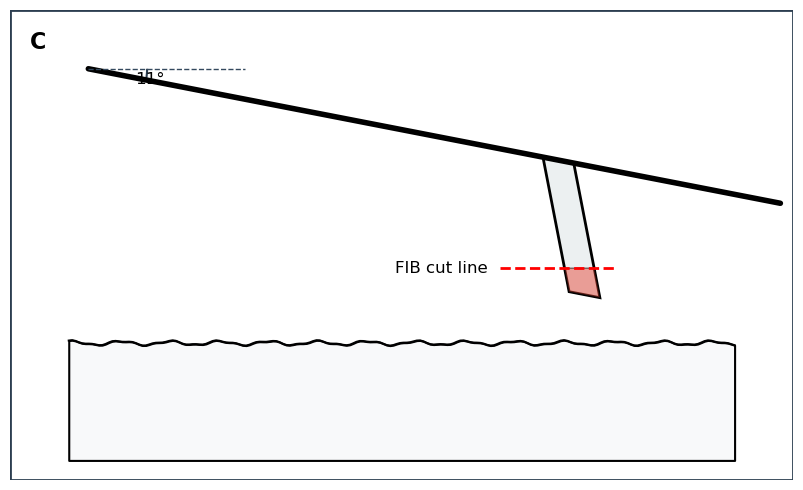

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Create the figure
fig, ax = plt.subplots(figsize=(10, 5))

# Angles and geometric parameters
angle_deg = 11
angle_rad = np.radians(angle_deg)
L_cantilever = 18
x_start = 2
y_start = 8

# Draw Sample (with a slightly wavy surface for realism)
x_wave = np.linspace(1.5, 18.5, 200)
y_wave = 1 + 0.05 * np.sin(x_wave * 5) + 0.02 * np.cos(x_wave * 12)
ax.plot(x_wave, y_wave, color='black', lw=1.5)
ax.fill_between(x_wave, y_wave, -2, color='#f8f9fa', edgecolor='black', lw=1.5)

# Cantilever line (tilted by 11 degrees down)
x_end = x_start + L_cantilever * np.cos(angle_rad)
y_end = y_start - L_cantilever * np.sin(angle_rad)
ax.plot([x_start, x_end], [y_start, y_end], color='black', lw=4, solid_capstyle='round')

# Horizontal reference line for the 11° angle
ax.plot([x_start, x_start + 4], [y_start, y_start], color='#34495e', lw=1, linestyle='--')
arc = patches.Arc((x_start, y_start), 3, 3, angle=0, theta1=-angle_deg, theta2=0, color='#2c3e50', lw=1.5)
ax.add_patch(arc)
ax.text(x_start + 1.2, y_start - 0.4, '11°', fontsize=12)

# Calculate Probe position and orientation
probe_x = 14
probe_y = y_start - (probe_x - x_start) * np.tan(angle_rad)

# Direction vectors for the cantilever and the perpendicular probe
v_c = np.array([np.cos(-angle_rad), np.sin(-angle_rad)])  # Vector along cantilever
v_p = np.array([np.sin(angle_rad), -np.cos(angle_rad)])   # Vector perpendicular (pointing down)

# Calculate the 4 corners of the original cylindrical probe before the cut
w = 0.8  # probe width
h = 3.5  # probe height before cut
pt_tl = np.array([probe_x, probe_y]) - (w/2) * v_c
pt_tr = np.array([probe_x, probe_y]) + (w/2) * v_c
pt_bl = pt_tl + h * v_p
pt_br = pt_tr + h * v_p

probe_poly = np.array([pt_tl, pt_tr, pt_br, pt_bl])
ax.add_patch(patches.Polygon(probe_poly, closed=True, facecolor='#ecf0f1', edgecolor='black', lw=2))

# Define the Horizontal FIB Cut Line
y_cut = pt_bl[1] + 0.6  # Height of the cut
ax.plot([probe_x - 1.5, probe_x + 1.5], [y_cut, y_cut], color='red', lw=2, linestyle='--')
ax.text(probe_x - 1.8, y_cut, 'FIB cut line', color='black', fontsize=12, ha='right', va='center')

# Shade the removed material (the wedge at the bottom)
x_cut_left = pt_tl[0] + (y_cut - pt_tl[1]) * (pt_bl[0] - pt_tl[0]) / (pt_bl[1] - pt_tl[1])
x_cut_right = pt_tr[0] + (y_cut - pt_tr[1]) * (pt_br[0] - pt_tr[0]) / (pt_br[1] - pt_tr[1])

wedge_poly = np.array([[x_cut_left, y_cut], [x_cut_right, y_cut], pt_br, pt_bl])
ax.add_patch(patches.Polygon(wedge_poly, closed=True, facecolor='#e74c3c', alpha=0.5, edgecolor='black', lw=1))

# Panel Label 'C'
ax.text(0.5, 8.5, 'C', fontsize=16, fontweight='bold', fontfamily='sans-serif')

# Clean up axes and enforce aspect ratio to visually preserve the true 11°
ax.set_aspect('equal')
ax.set_xlim(0, 20)
ax.set_ylim(-2.5, 9.5)
ax.axis('off')

# Outer bounding box similar to the original panel
rect = patches.Rectangle((0, -2.5), 20, 12, linewidth=2, edgecolor='#2c3e50', facecolor='none')
ax.add_patch(rect)

# Save and Display
plt.tight_layout()
plt.savefig('improved_panel_c.png', dpi=300)
plt.show()

In [2]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# F = kd
# w = z - d

# F = 4/3 E/(1-nu^2) * sqrt(R) (w)^(3/2)


nu = 0.5
R_1 = 2.5e-6 #um
R_2 = 5.0e-6

w_1 = 0.1 * R_1 # um
z_1 = 2.0 * w # 0.5 um
d_1 = w # 0.25 um

w_2 = 0.1 * R_2 # um
z_2 = 2.0 * w # 0.5 um
d_2 = w # 0.25 um


E = np.linspace(1, 100e3, 100)
k_1 = 4.0 * 3.0 / (1 - nu * nu) * np.sqrt(R_1) * np.pow(w_1, 3.0 / 2.0) / d_1 * E
k_2 = 4.0 * 3.0 / (1 - nu * nu) * np.sqrt(R_2) * np.pow(w_2, 3.0 / 2.0) / d_2 * E

print(np.log10(0.1))
print(np.log10(0.01))

plt.rcParams.update({'font.size': 16})

fig = plt.figure()
ax = fig.add_subplot(111)
ax.set_xscale('log')
ax.set_yscale('log')
plt.grid(True)
plt.plot(E/1e3, k_1, 'r-')
plt.plot(E/1e3, k_2, 'b-')
plt.legend(['R = 2.5 um', 'R = 5 um'])
# plt.axvline(x=np.log10(1))
# plt.axhline(y=np.log10(0.1))
# plt.axhline(y=np.log10(0.01))
# plt.axvline(x=np.log10(0.5))
plt.title("Cantilever Selection")
plt.xlabel("Expected Young's Modulus E [kPa]")
plt.ylabel("Cantilever stiffness k [N/m]")
plt.show()

NameError: name 'w' is not defined

*Node
1, 0.00000000, 50.00000000, 0.00000000
2, 1.11111111, 50.00000000, 0.00000000
3, 2.22222222, 50.00000000, 0.00000000
4, 3.33333333, 50.00000000, 0.00000000
5, 4.44444444, 50.00000000, 0.00000000
6, 5.55555556, 50.00000000, 0.00000000
7, 6.66666667, 50.00000000, 0.00000000
8, 7.77777778, 50.00000000, 0.00000000
9, 8.88888889, 50.00000000, 0.00000000
10, 10.00000000, 50.00000000, 0.00000000
11, 0.00000000, 55.00000000, 0.00000000
12, 0.86824089, 55.07596123, 0.00000000
13, 1.71010072, 55.30153690, 0.00000000
14, 2.50000000, 55.66987298, 0.00000000
15, 3.21393805, 56.16977778, 0.00000000
16, 3.83022222, 56.78606195, 0.00000000
17, 4.33012702, 57.50000000, 0.00000000
18, 4.69846310, 58.28989928, 0.00000000
19, 4.92403877, 59.13175911, 0.00000000
20, 5.00000000, 60.00000000, 0.00000000


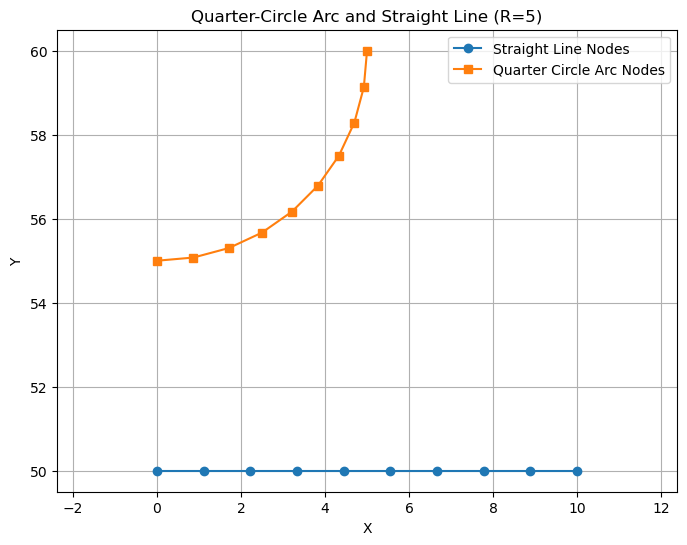

In [2]:
import numpy as np
from matplotlib import pyplot as plt

# Same number of nodes for line and arc
num_nodes = 10

# Line: X from 0 to 10, Y = 50
x_line = np.linspace(0, 10, num_nodes)
y_line = np.full_like(x_line, 50.0)
z_line = np.zeros_like(x_line)

# Arc: quarter circle from (0,55) to (5,60)
R = 5.0
theta = np.linspace(-np.pi/2, 0, num_nodes)
x_arc = R * np.cos(theta)            # From 0 to 5
y_arc = 60 + R * np.sin(theta)       # From 55 to 60
z_arc = np.zeros_like(x_arc)

# Combine both
x_all = np.concatenate([x_line, x_arc])
y_all = np.concatenate([y_line, y_arc])
z_all = np.concatenate([z_line, z_arc])

# Output Abaqus node list
print("*Node")
for i, (x, y, z) in enumerate(zip(x_all, y_all, z_all), start=1):
    print(f"{i}, {x:.8f}, {y:.8f}, {z:.8f}")

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(x_line, y_line, 'o-', label="Straight Line Nodes")
plt.plot(x_arc, y_arc, 's-', label="Quarter Circle Arc Nodes")
plt.axis('equal')
plt.grid(True)
plt.title("Quarter-Circle Arc and Straight Line (R=5)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


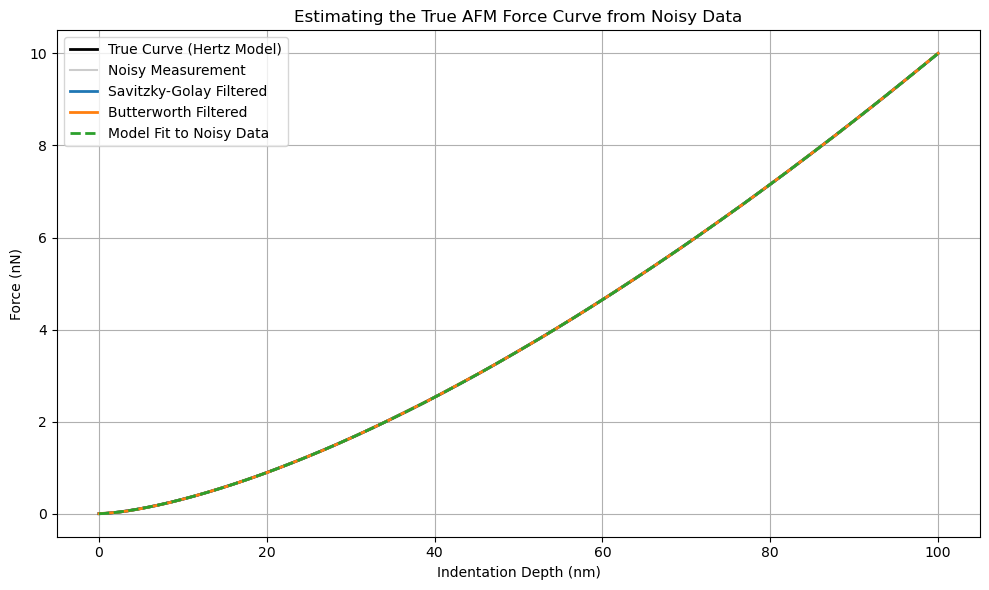

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, butter, filtfilt
from scipy.optimize import curve_fit

# Simulated Hertzian contact model: F = A * d^1.5
def hertz_model(d, A):
    return A * d**1.5

# Generate true signal
np.random.seed(42)
indent = np.linspace(0, 100, 500)  # nm
A_true = 0.01  # contact stiffness coefficient
force_true = hertz_model(indent, A_true)

# Add synthetic Gaussian noise
noise_level = 0.005  # nN
force_noisy = force_true + np.random.normal(0, noise_level, size=indent.size)

# Apply Savitzky-Golay filter
force_savgol = savgol_filter(force_noisy, window_length=31, polyorder=3)

# Apply Butterworth filter
b, a = butter(N=2, Wn=0.1)
force_butter = filtfilt(b, a, force_noisy)

# Fit Hertz model to noisy data
fit_mask = indent > 10  # ignore near-zero values where noise dominates
popt, _ = curve_fit(hertz_model, indent[fit_mask], force_noisy[fit_mask], p0=[0.01])
force_fit = hertz_model(indent, *popt)

# Plot everything
plt.figure(figsize=(10, 6))
plt.plot(indent, force_true, label="True Curve (Hertz Model)", linewidth=2, color='black')
plt.plot(indent, force_noisy, label="Noisy Measurement", alpha=0.4, color='gray')
plt.plot(indent, force_savgol, label="Savitzky-Golay Filtered", linewidth=2)
plt.plot(indent, force_butter, label="Butterworth Filtered", linewidth=2)
plt.plot(indent, force_fit, label="Model Fit to Noisy Data", linestyle='--', linewidth=2)

plt.xlabel("Indentation Depth (nm)")
plt.ylabel("Force (nN)")
plt.title("Estimating the True AFM Force Curve from Noisy Data")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
